## Assignment: Image recognition

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [9]:
!pip install -q livelossplot 
!pip install -q rasterio
!pip install -q albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 56.9 MB/s eta 0:00:00


In [10]:
import numpy as np
import scipy
import pandas as pd
import matplotlib
import seaborn as sns
import tqdm
import sklearn
import cv2
import rasterio
import albumentations
import google.protobuf
import livelossplot

# Check package versions
print("numpy version:", np.__version__)
print("scipy version:", scipy.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", sns.__version__)
print("tqdm version:", tqdm.__version__)
print("scikit-learn version:", sklearn.__version__)
print("opencv-python version:", cv2.__version__)
print("rasterio version:", rasterio.__version__)
print("albumentations version:", albumentations.__version__)
print("protobuf version:",google.protobuf.__version__)
print("livelossplot is installed:", livelossplot.__version__)

# Verify that there are no import errors
try:
    import numpy
    import scipy
    import pandas
    import matplotlib
    import seaborn
    import tqdm
    import sklearn
    import cv2
    import rasterio
    import albumentations
    import google.protobuf
    import livelossplot
    print("Todos los paquetes están instalados correctamente.")
except ImportError as e:
    print(f"Error de importación: {e}")


numpy version: 2.0.2
scipy version: 1.15.3
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2
tqdm version: 4.67.1
scikit-learn version: 1.6.1
opencv-python version: 4.12.0
rasterio version: 1.4.4
albumentations version: 2.0.8
protobuf version: 5.29.5
livelossplot is installed: 0.5.6
Todos los paquetes están instalados correctamente.


In [11]:
import os
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
print(tf.config.list_physical_devices('GPU'))


2025-12-27 00:37:20.089668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766795840.309724      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766795840.380965      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766795840.924777      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766795840.924818      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766795840.924821      24 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [12]:
INPUT_DIR = "/kaggle/input/xview-recognition/"
OUTPUT_DIR = "/kaggle/working/"

JSON_TRAIN = INPUT_DIR + "xview_ann_train.json"
TEST_DIR = INPUT_DIR + "xview_test"

PREDICTION_PATH = OUTPUT_DIR + "predictions_cnn.json"
IN_PATH = PREDICTION_PATH
OUT_PATH = OUTPUT_DIR + "prediction_cnn_words.json"
MODEL_PATH = OUTPUT_DIR + "tl_eficientnet.keras"
MODEL_PATH_FASE_1 = OUTPUT_DIR + "phase1_best.keras"
MODEL_PATH_FASE_2 = OUTPUT_DIR + "phase2_best.keras"

In [ ]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

#### Seed

In [14]:
import tensorflow as tf, numpy as np, random
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

##### Image Loading

In [ ]:
import os
import warnings
import rasterio

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

    filepath = os.path.join(INPUT_DIR, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"El archivo no existe: {filepath}")

    with rasterio.open(filepath) as src:
        image = src.read() 
        image = np.transpose(image, (1, 2, 0))

    return image.astype(np.float32)


##### Classes

In [16]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

## Image Preprocessing

##### Image Resizing and Normalization

In [ ]:
import cv2
IMG_SIZE = 224 
def preprocess_image(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    img = np.clip(img, 0, 255).astype(np.float32) 
    return img

##### Function to Add Padding to Images

In [18]:
def crop_with_margin(img, bb, margin=0.15):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = map(int, bb)
    mx = int((x2-x1)*margin); my = int((y2-y1)*margin)
    x1 = max(0, x1-mx); y1 = max(0, y1-my)
    x2 = min(w, x2+mx); y2 = min(h, y2+my)
    return img[y1:y2, x1:x2]

##### Image Generator Function for Training and Testing

In [ ]:
import numpy as np
import tensorflow as tf
import albumentations as A
import cv2
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.4), # Added Hue/Saturation/Value shift
    A.RandomGamma(gamma_limit=(80, 120), p=0.4), # Added random Gamma adjustment
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=30, p=0.7, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.OneOf([ # Apply one of these two
        A.MotionBlur(p=0.2),
        A.MedianBlur(blur_limit=3, p=0.1),
    ], p=0.2),
    A.CoarseDropout(max_holes=8, max_height=8, max_width=8, min_holes=1, min_height=1, min_width=1, fill_value=0, p=0.2),
])
def generator_images(objs, batch_size, do_shuffle=False, num_classes=None, apply_augmentation=False):
    assert num_classes is not None, "Pasa num_classes al generador para one-hot."
    N = len(objs)
    while True:
        idxs = np.arange(N)
        if do_shuffle:
            np.random.shuffle(idxs)

        for k in range(0, N, batch_size):
            batch_ids = idxs[k:k+batch_size]
            images, labels = [], []

            for j in batch_ids:
                filename, obj = objs[j]
                img_full = load_geoimage(filename)
                img = crop_with_margin(img_full, obj.bb, 0.15)
                # Resize BEFORE augmentation
                img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

                if apply_augmentation:
                    augmented = train_transform(image=img_resized.astype(np.uint8))
                    img_to_normalize = augmented['image']
                else:
                    img_to_normalize = img_resized
                
                img_float = img_to_normalize.astype(np.float32)  # 0..255
                labels.append(cat_to_idx(obj.category))
                images.append(img_float)

            X = np.asarray(images, dtype=np.float32)
            y = tf.keras.utils.to_categorical(labels, num_classes=num_classes).astype(np.float32)
            yield X, y

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_24/4286849907.py:10: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=30, p=0.7, border_mode=cv2.BORDER_CONSTANT, value=0),
/tmp/ipykernel_24/4286849907.py:11: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
/tmp/ipykernel_24/4286849907.py:16: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=8, max_width=8, min_holes=1, min_height=1, min_width=1, fill_value=0, p=0.2),


## Training

### Hyperparameters

In [ ]:
batch_size = 64

#### Import Train/Validation Images

In [21]:
import json

# Load database
json_file = JSON_TRAIN
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

#### Images for Each Class

In [22]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


### Train/Validation Split

##### Stratified Split by Class

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

objs = [(ann.filename, obj) for ann in anns for obj in ann.objects]

# Category name normalizer
def norm_cat(c: str) -> str:
    return str(c).strip().lower().replace(" ", "").replace("_", "").replace("-", "")

# Map actual categories to indices
class_names = [categories[i] for i in sorted(categories.keys())]  
index_to_category = {i: categories[i] for i in sorted(categories.keys())}  
category_to_index = {name: idx for idx, name in index_to_category.items()}  
print(category_to_index)
print(index_to_category)

def norm_cat(s: str) -> str:
    return s.strip().lower().replace('-', ' ').replace('_', ' ')

alias_to_index = {norm_cat(name): idx for name, idx in category_to_index.items()}

def cat_to_idx(c: str):
    return category_to_index.get(c, alias_to_index.get(norm_cat(c)))

# Build labels and groups
y_idx = np.array([cat_to_idx(obj.category) for _, obj in objs], dtype=int)
groups = np.array([fn for fn, _ in objs])  # group = filename

# Try splitting the data by class
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
train_idx, valid_idx = next(sgkf.split(X=np.zeros(len(objs)), y=y_idx, groups=groups))

# Build final lists
objs_train = [objs[i] for i in train_idx]
objs_valid = [objs[i] for i in valid_idx]

print(f"Train objs: {len(objs_train)} | Val objs: {len(objs_valid)}")

{'Cargo plane': 0, 'Small car': 1, 'Bus': 2, 'Truck': 3, 'Motorboat': 4, 'Fishing vessel': 5, 'Dump truck': 6, 'Excavator': 7, 'Building': 8, 'Helipad': 9, 'Storage tank': 10, 'Shipping container': 11, 'Pylon': 12}
{0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}
Train objs: 16871 | Val objs: 1875


##### Check for Filename Leakage

In [24]:
train_fns = {fn for fn, _ in objs_train}
valid_fns = {fn for fn, _ in objs_valid}
leak = train_fns & valid_fns
print(f"Train objs: {len(objs_train)}  | Valid objs: {len(objs_valid)}")
print("Leak filenames:", len(leak))
assert len(leak) == 0, "¡Hay imágenes (filenames) compartidas entre train y valid!"

Train objs: 16871  | Valid objs: 1875
Leak filenames: 0


##### Model

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.optimizers import AdamW

NUM_CLASSES = len(categories)  # 13 
INPUT_SIZE = IMG_SIZE  # 224
INPUT_SHAPE = (INPUT_SIZE, INPUT_SIZE, 3)

def build_transfer_learning_model(input_shape, num_classes):
    
    inputs = layers.Input(shape=input_shape, name="input_image")

    # ResNet50V2 preprocessing expects 0..255 and maps it to [-1, 1]
    x = layers.Lambda(preprocess_input, name="resnet50v2_preprocess")(inputs)

    base_model = ResNet50V2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False  # Phase 1

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Dropout(0.40, name="drop1")(x)

    x = layers.Dense(
        256, activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name="fc1"
    )(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Dropout(0.40, name="drop2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="pred")(x)

    model = keras.Model(inputs, outputs, name="TL_ResNet50V2")
    return model, base_model


##### Optimizer

##### Generators

In [26]:
# Generators
train_generator = generator_images(objs_train, batch_size, do_shuffle=True, num_classes=NUM_CLASSES, apply_augmentation=True)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False, num_classes=NUM_CLASSES, apply_augmentation=False)

##### Callbacks

In [27]:
from time import time
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from livelossplot import PlotLossesKeras


tensorboard = TensorBoard(log_dir='logs/{}'.format(time()))
model_checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', verbose=1, save_best_only=True)
model_checkpoint_fase_1 = ModelCheckpoint(MODEL_PATH_FASE_1, monitor='val_accuracy', verbose=1, save_best_only=True)
model_checkpoint_fase_2 = ModelCheckpoint(MODEL_PATH_FASE_2, monitor='val_accuracy', verbose=1, save_best_only=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                         min_lr=2e-5, verbose=1)
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
liveloss = PlotLossesKeras()
terminate = TerminateOnNaN()
callbacks_fase_1 = [model_checkpoint_fase_1,reduce_lr, early_stop, terminate, tensorboard,liveloss]
callbacks_fase_2 = [model_checkpoint_fase_2,reduce_lr, early_stop, terminate, tensorboard,liveloss]
callbacks = [model_checkpoint,reduce_lr, early_stop, terminate, tensorboard,liveloss]

##### Training

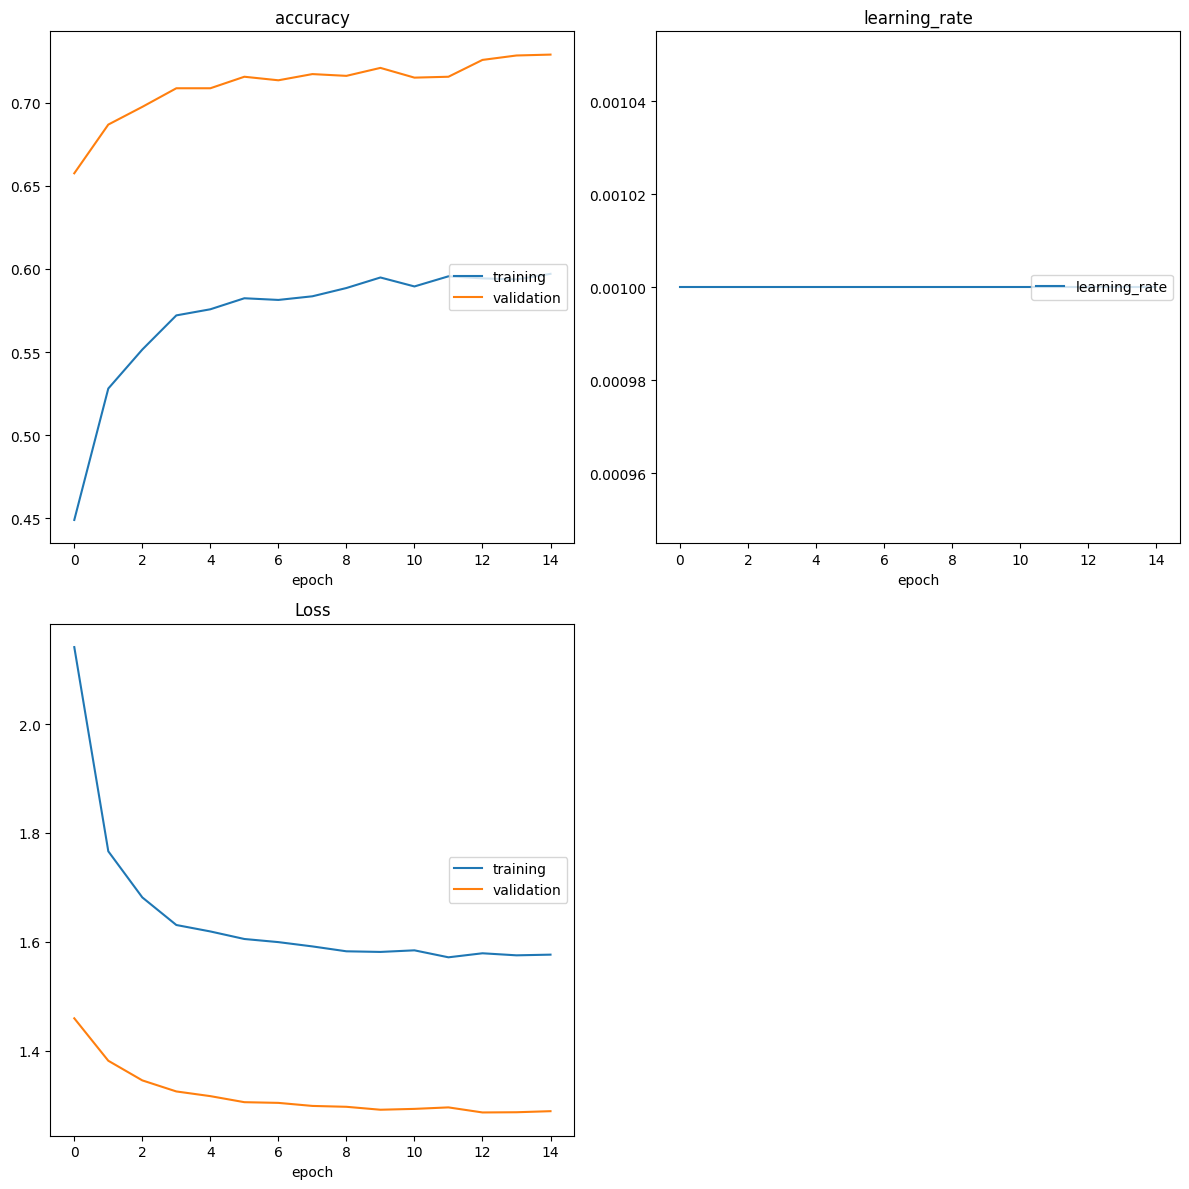

accuracy
	training         	 (min:    0.449, max:    0.597, cur:    0.597)
	validation       	 (min:    0.658, max:    0.729, cur:    0.729)
learning_rate
	learning_rate    	 (min:    0.001, max:    0.001, cur:    0.001)
Loss
	training         	 (min:    1.571, max:    2.142, cur:    1.576)
	validation       	 (min:    1.286, max:    1.459, cur:    1.288)
264/264 ━━━━━━━━━━━━━━━━━━━━ 113s 427ms/step - accuracy: 0.5941 - loss: 1.5738 - val_accuracy: 0.7291 - val_loss: 1.2885 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 13.

✅ Fase 1 completada
Mejor modelo fase 1: época 15 - val_accuracy: 0.7291


In [ ]:
# PHASE 1
import math
import numpy as np

print("\n" + "=" * 60)
print("FASE 1: Entrenamiento del clasificador (base congelada)")
print("=" * 60)

# Create model
model, base_model = build_transfer_learning_model(INPUT_SHAPE, NUM_CLASSES)
model.summary()

# Compile with a high learning rate
optimizer_phase1 = AdamW(learning_rate=0.001, weight_decay=1e-4)
model.compile(
    optimizer=optimizer_phase1,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

train_steps = math.ceil(len(objs_train)/batch_size)
valid_steps = math.ceil(len(objs_valid)/batch_size)

# Train phase 1
epochs_phase1 = 15
print(f"\nEntrenando fase 1: {epochs_phase1} épocas")

h1 = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=epochs_phase1,
    callbacks=callbacks_fase_1,
    verbose=1
)

print(f"\n✅ Fase 1 completada")
best_idx_1 = int(np.argmax(h1.history['val_accuracy']))
best_acc_1 = np.max(h1.history['val_accuracy'])
print(f"Mejor modelo fase 1: época {best_idx_1+1} - val_accuracy: {best_acc_1:.4f}")


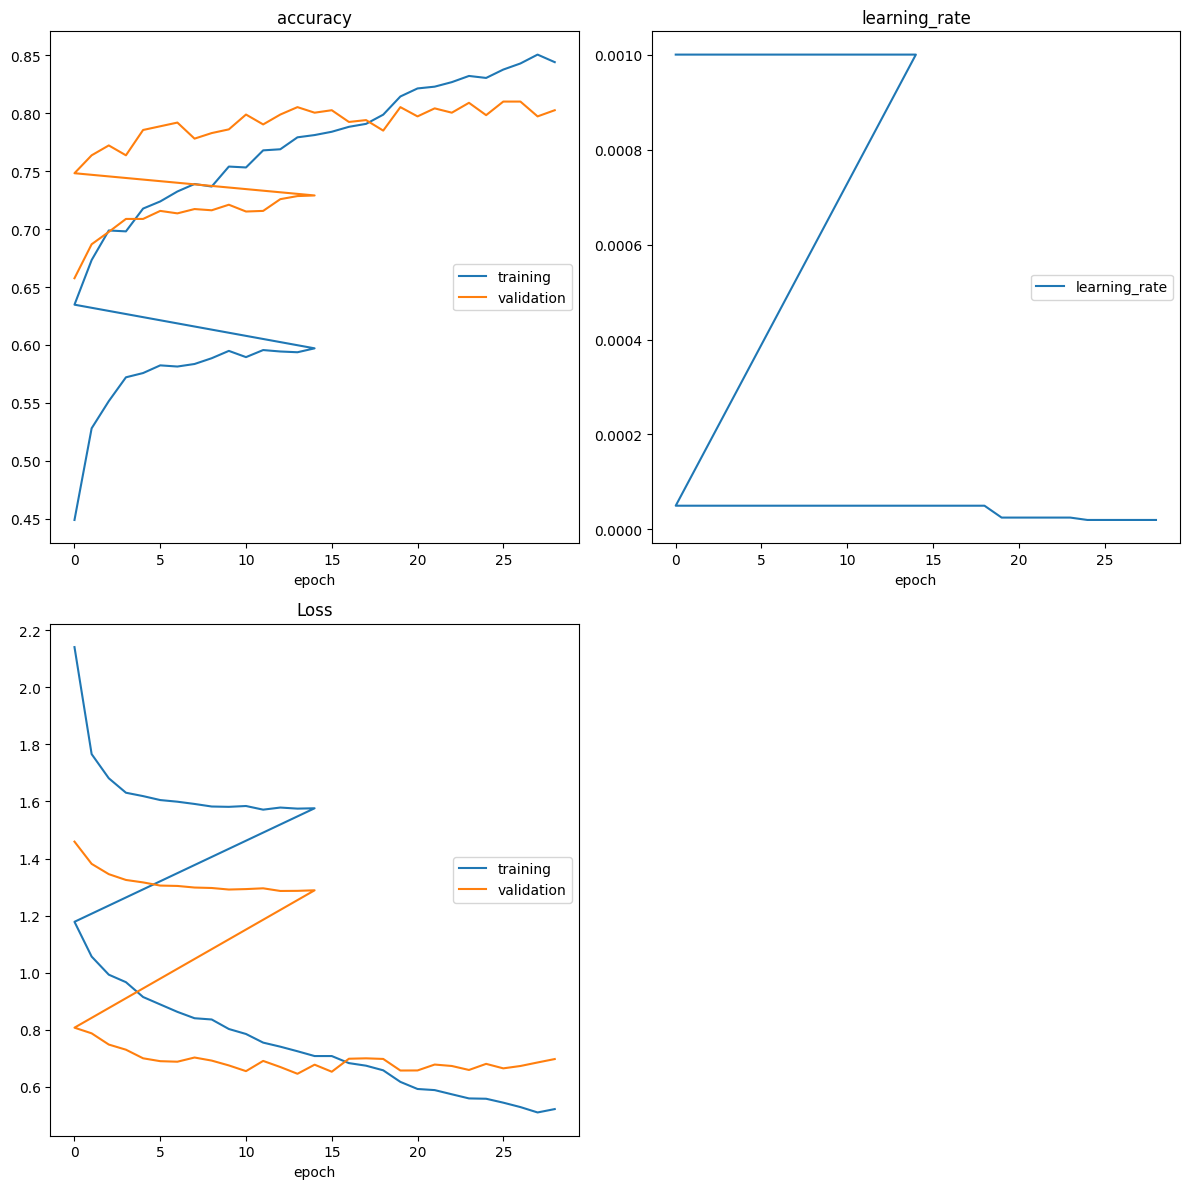

accuracy
	training         	 (min:    0.449, max:    0.851, cur:    0.844)
	validation       	 (min:    0.658, max:    0.810, cur:    0.803)
learning_rate
	learning_rate    	 (min:    0.000, max:    0.001, cur:    0.000)
Loss
	training         	 (min:    0.509, max:    2.142, cur:    0.521)
	validation       	 (min:    0.645, max:    1.459, cur:    0.696)
264/264 ━━━━━━━━━━━━━━━━━━━━ 116s 440ms/step - accuracy: 0.8411 - loss: 0.5287 - val_accuracy: 0.8027 - val_loss: 0.6965 - learning_rate: 2.0000e-05
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 14.

✅ Fase 2 completada
Mejor modelo fase 2: época 26 - val_accuracy: 0.8101

💾 Modelo final guardado en: /kaggle/working/tl_eficientnet.keras


In [ ]:
# PHASE 2: Fine-tuning
print("\n" + "=" * 60)
print("FASE 2: Fine-tuning (descongelar parte alta + congelar BatchNorm)")
print("=" * 60)

# Load phase 1 weights
model.load_weights(MODEL_PATH_FASE_1)

# Unfreeze backbone
base_model.trainable = True

# Freeze backbone BatchNorm layers
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Unfreeze only the final part of the backbone
n_layers = len(base_model.layers)
fine_tune_from = int(0.8 * n_layers) # last 20% trainable

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

print(f"\nCapas entrenables en el backbone: {sum(l.trainable for l in base_model.layers)} / {len(base_model.layers)}")
print(f"Capas entrenables totales del modelo: {sum(l.trainable for l in model.layers)} / {len(model.layers)}")

# Recompile
optimizer_phase2 = AdamW(learning_rate=5e-5, weight_decay=1e-4)

model.compile(
    optimizer=optimizer_phase2,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    metrics=['accuracy']
)

# Train phase 2
epochs_phase2 = 30
print(f"\nEntrenando fase 2: {epochs_phase2} épocas")

h2 = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=epochs_phase2,
    callbacks=callbacks_fase_2,
    verbose=1
)

print(f"\n✅ Fase 2 completada")
best_idx_2 = int(np.argmax(h2.history['val_accuracy']))
best_acc_2 = float(np.max(h2.history['val_accuracy']))
print(f"Mejor modelo fase 2: época {best_idx_2+1} - val_accuracy: {best_acc_2:.4f}")

# Save final model
model.save(MODEL_PATH)
print(f"\n💾 Modelo final guardado en: {MODEL_PATH}")


##### Accuracy and Loss Plots

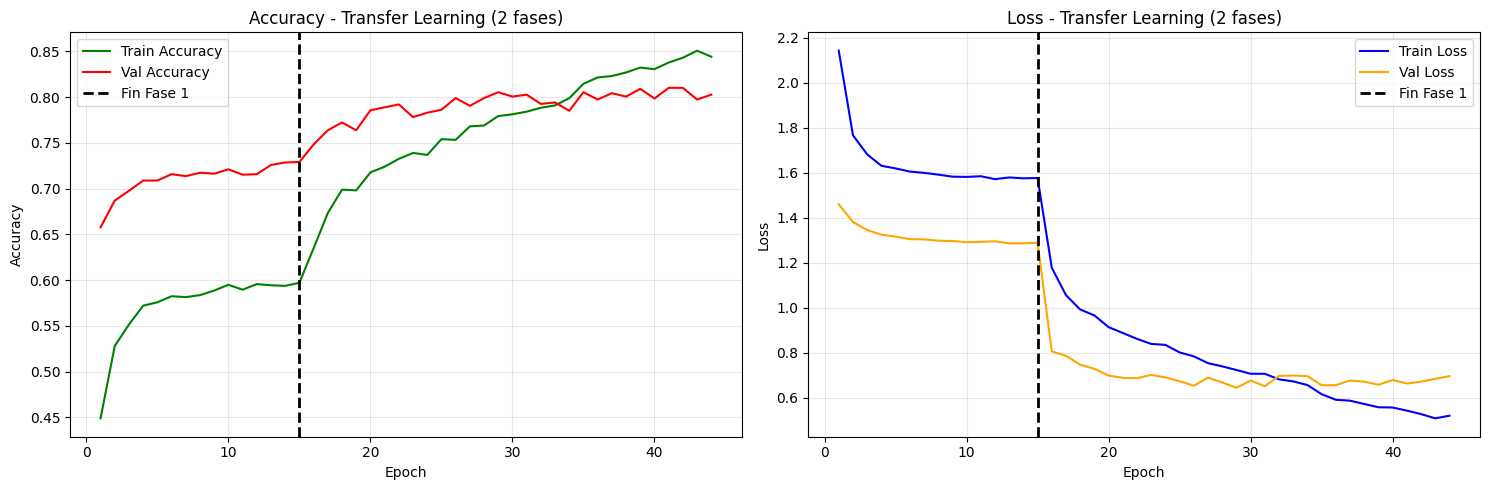


RESUMEN FINAL
Fase 1 - Mejor val_accuracy: 0.7291 (época 15)
Fase 2 - Mejor val_accuracy: 0.8101 (época 26)
Mejora total: 8.11%


In [ ]:
# Combined visualization of both phases
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Combine histories
all_acc = h1.history['accuracy'] + h2.history['accuracy']
all_val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
all_loss = h1.history['loss'] + h2.history['loss']
all_val_loss = h1.history['val_loss'] + h2.history['val_loss']

total_epochs = len(all_acc)
epochs_range = range(1, total_epochs + 1)

# Divider line between phases
phase_split = len(h1.history['accuracy'])

# Plot 1: Accuracy
ax1.plot(epochs_range, all_acc, 'g-', label='Train Accuracy')
ax1.plot(epochs_range, all_val_acc, 'r-', label='Val Accuracy')
ax1.axvline(x=phase_split, color='black', linestyle='--', linewidth=2, label='Fin Fase 1')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy - Transfer Learning (2 fases)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Loss
ax2.plot(epochs_range, all_loss, 'b-', label='Train Loss')
ax2.plot(epochs_range, all_val_loss, 'orange', linestyle='-', label='Val Loss')
ax2.axvline(x=phase_split, color='black', linestyle='--', linewidth=2, label='Fin Fase 1')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss - Transfer Learning (2 fases)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("RESUMEN FINAL")
print("=" * 60)
print(f"Fase 1 - Mejor val_accuracy: {best_acc_1:.4f} (época {best_idx_1+1})")
print(f"Fase 2 - Mejor val_accuracy: {best_acc_2:.4f} (época {best_idx_2+1})")
print(f"Mejora total: {(best_acc_2 - best_acc_1)*100:.2f}%")

## Validation


In [ ]:
import numpy as np

def tta_predict_single(model, x_hw3):
    """
    x_hw3: imagen YA preprocesada (H=W=IMG_SIZE, [0,1], float32), shape (H,W,3)
    Devuelve el vector de probabilidades promediado sobre varias vistas.
    """
    Xs = []
    for k in [0, 1, 2, 3]:
            xr = np.rot90(x_hw3, k).copy()
            Xs.append(xr)               # rot k
            Xs.append(xr[:, ::-1, :])   # rot k + flip H

    Xb = np.stack(Xs, axis=0)           # (V,H,W,3)
    p = model.predict(Xb, verbose=0)    # (V,C)
    return p.mean(axis=0)               # (C,)

In [34]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import tensorflow
model.load_weights(MODEL_PATH)  # or whichever checkpoint you use
y_true, y_pred = [], []

for (filename, obj_pred) in objs_valid:
    # Load full image
    full = load_geoimage(filename)
    H, W = full.shape[:2]

    # Crop the bounding box with padding (same as in the generator)
    x1, y1, x2, y2 = map(int, obj_pred.bb)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)
    crop = full[y1:y2, x1:x2]
    crop = crop_with_margin(full, obj_pred.bb, 0.15)
    x = preprocess_image(crop)
    x = np.expand_dims(x, 0)

    # Model prediction
    p_avg = tta_predict_single(model, x[0]) 
    pred_idx = int(np.argmax(p_avg))
    y_pred.append(pred_idx)

    # Ground-truth label
    true_idx = cat_to_idx(obj_pred.category)
    assert true_idx is not None, f"Clase no mapeada: {obj_pred.category}"
    y_true.append(true_idx)


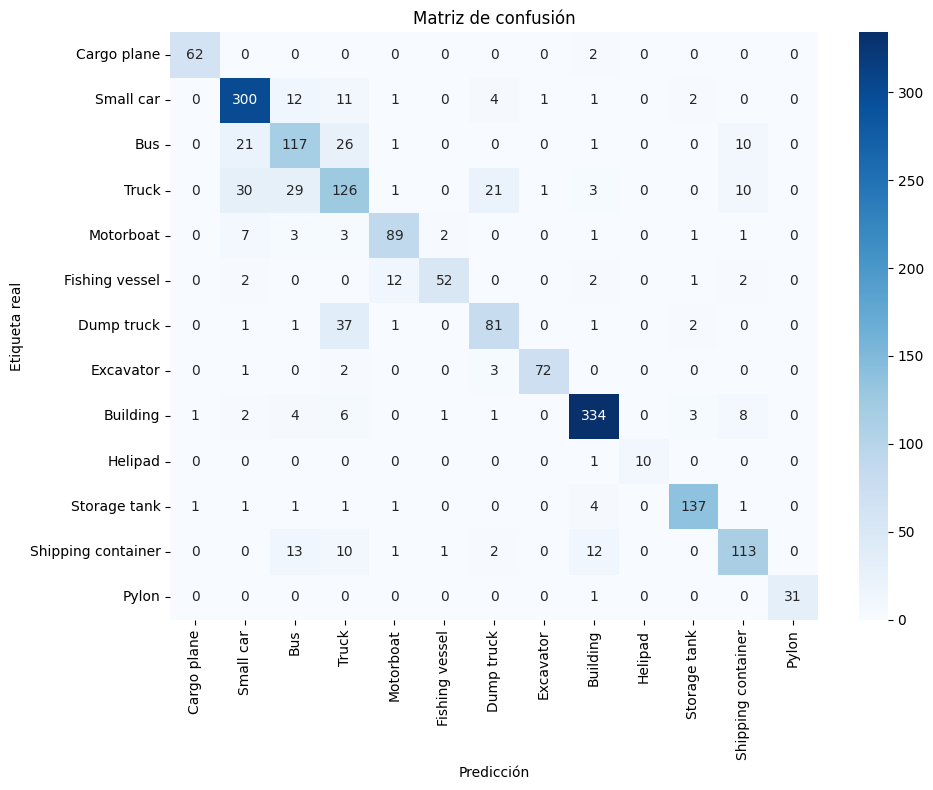

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(range(len(class_names)))  # 0..N-1
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()


In [37]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 81.280%
Mean Recall: 82.529%
Mean Precision: 85.404%
> Cargo plane: Recall: 96.875% Precision: 96.875% Specificity: 99.890% Dice: 96.875%
> Small car: Recall: 90.361% Precision: 82.192% Specificity: 95.787% Dice: 86.083%
> Bus: Recall: 66.477% Precision: 65.000% Specificity: 96.292% Dice: 65.730%
> Truck: Recall: 57.014% Precision: 56.757% Specificity: 94.196% Dice: 56.885%
> Motorboat: Recall: 83.178% Precision: 83.178% Specificity: 98.982% Dice: 83.178%
> Fishing vessel: Recall: 73.239% Precision: 92.857% Specificity: 99.778% Dice: 81.890%
> Dump truck: Recall: 65.323% Precision: 72.321% Specificity: 98.230% Dice: 68.644%
> Excavator: Recall: 92.308% Precision: 97.297% Specificity: 99.889% Dice: 94.737%
> Building: Recall: 92.778% Precision: 92.011% Specificity: 98.086% Dice: 92.393%
> Helipad: Recall: 90.909% Precision: 100.000% Specificity: 100.000% Dice: 95.238%
> Storage tank: Recall: 93.197% Precision: 93.836% Specificity: 99.479% Dice: 93.515%
> Shipping containe

#### Testing
Try to improve the results provided in the competition.

In [38]:
import os
import numpy as np

anns = []
for (dirpath, dirnames, filenames) in os.walk(TEST_DIR):
    for filename in filenames:
        image = GenericImage(dirpath + '/' + filename)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [ ]:
import os
import numpy as np

model.load_weights(MODEL_PATH)
predictions_data = {"images": {}, "annotations": {}}

for idx, ann in enumerate(anns):
    filename = os.path.basename(ann.filename)  # <- filename, without the path
    image_data = {
        "image_id": filename,
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    # Load image
    image = load_geoimage(ann.filename)
    image = preprocess_image(image)

    for obj_pred in ann.objects:
        # Generate prediction
        crop = crop_with_margin(image, obj_pred.bb, margin=0.15)
        predictions = tta_predict_single(model, crop)

        # Save prediction
        pred_category = int(np.argmax(predictions)) 
        pred_score = np.max(predictions)
        annotation_data = {
            "image_id": filename,
            "category_id": pred_category,
            "bbox": [int(x) for x in obj_pred.bb]
        }
        predictions_data["annotations"][idx] = annotation_data


In [40]:
with open(PREDICTION_PATH, "w") as outfile:
    json.dump(predictions_data, outfile)